In [1]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc, mcscf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class CASSpectralMoments:

    def __init__(
        self,
        mf,
        ncas,
        nelecas,
        mo_coeff=None,
    ):

        self.mf = mf
        self.mol = mf.mol

        self.ncas = ncas
        self.nelecas = nelecas

        # CASCI object
        self.cas = mcscf.CASCI(
            mf,
            ncas,
            nelecas,
        )

        if mo_coeff is None:
            mo_coeff = mf.mo_coeff

        self.mo_coeff = mo_coeff

        # Active-space Hamiltonian
        self.h1eff, self.ecore = self.cas.get_h1eff(self.mo_coeff)

        eri_cas = self.cas.get_h2eff(self.mo_coeff)
        eri_cas = ao2mo.restore(1, eri_cas, ncas)

        self.one_mo = self.h1eff
        self.two_mo = np.swapaxes(eri_cas, 1, 3)

        # Active-space dimensions
        self.nmo = ncas
        self.nelec = nelecas

        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.constant_energy = self.ecore

        # Build qubit Hamiltonian
        self.qubit_hamiltonian = (
            self.build_qubit_hamiltonian()
        )

        self.Hmat = qml.matrix(
            self.qubit_hamiltonian,
            wire_order=self.wires,
        )

        self.a, self.adag = (
            self.build_fermionic_operators()
        )

        self.device = qml.device(
            "default.qubit",
            wires=self.n_spin_orbitals,
        )

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        # Mo basis
        
        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        H = observable(
            h1,
            h2,
            mapping="jordan_wigner",
        )

        # add frozen-core/nuclear constant
        H += self.ecore * qml.Identity(0)

        return H

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy
            energy_history.append(total_energy)

            if step % 10 == 0:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.constant_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

## Hydrogen attack of Boron nitride


In [3]:
# Finding the right orbitals 

from pyscf import gto, scf, mcscf

mol = gto.M(
    atom="""
    B 0.0 0.0 0.0
    N 0.0 0.0 1.3
    H 0.0 0.0 2.3
    """,
    basis="sto-3g",
    charge=0,
    spin=1,   # odd number of electrons: B(5)+N(7)+H(1)=13
)

mf = scf.ROHF(mol).run()

for i, (e, occ) in enumerate(zip(mf.mo_energy, mf.mo_occ)):
    print(f"{i:3d}  energy={e:12.6f}  occ={occ}")

converged SCF energy = -78.5731039081987
  0  energy=  -15.248006  occ=2.0
  1  energy=   -7.356824  occ=2.0
  2  energy=   -1.000254  occ=2.0
  3  energy=   -0.622670  occ=2.0
  4  energy=   -0.317162  occ=2.0
  5  energy=   -0.317162  occ=2.0
  6  energy=   -0.093037  occ=1.0
  7  energy=    0.387920  occ=0.0
  8  energy=    0.387920  occ=0.0
  9  energy=    0.624039  occ=0.0
 10  energy=    1.143171  occ=0.0


In [4]:
ncas = 3
nelecas = 4


def build_bn_h2_active_space(
    basis="sto-3g",
    bn_bond=1.281,
    hh_bond=0.741,
    h2_distance=2.0,
    ncas=3,
    nelecas=4,
):
    """
    Minimal BN + H2 coating-fragment toy model.

    Interpretation:
    - BN represents a tiny boron-nitride ceramic/coating motif.
    - H2 approaches the B site along the molecular axis.
    - h2_distance controls BN...H2 separation.

    ncas = 3 -> 6 qubits
    nelecas = 4 -> CAS(4e,3o)
    """

    mol = gto.Mole()
    mol.atom = f"""
    B   0.000000   0.000000   0.000000
    N   0.000000   0.000000   {bn_bond}

    H   0.000000   0.000000   {-h2_distance}
    H   0.000000   0.000000   {-h2_distance - hh_bond}
    """
    mol.basis = basis
    mol.charge = 0
    mol.spin = 0
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.RHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("RHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas


mol, mf, mc, h1eff, ecore, eri_cas = build_bn_h2_active_space()

print("Total electrons:", mol.nelectron)
print("HF energy:", mf.e_tot)
print("ecore:", ecore)
print("h1eff shape:", h1eff.shape)
print("eri_cas shape:", eri_cas.shape)
print("n qubits:", 2 * h1eff.shape[0])


converged SCF energy = -78.9596079592519
Total electrons: 14
HF energy: -78.95960795925185
ecore: -74.65309425530442
h1eff shape: (3, 3)
eri_cas shape: (3, 3, 3, 3)
n qubits: 6


converged SCF energy = -78.9593594470849
CASCI E = -78.9972433021886  E(CI) = -4.40856991367427  S^2 = 2.0000000
H2 distance = 3.00 Å | HF = -78.9593594471 | CASCI = -78.9972433022 | corr = -0.0378838551
converged SCF energy = -78.9593115847598
CASCI E = -78.9946604668193  E(CI) = -4.39533159781496  S^2 = 2.0000000
H2 distance = 2.50 Å | HF = -78.9593115848 | CASCI = -78.9946604668 | corr = -0.0353488821
converged SCF energy = -78.9596079592519
CASCI E = -78.9844158458055  E(CI) = -4.33132159050106  S^2 = 2.0000000
H2 distance = 2.00 Å | HF = -78.9596079593 | CASCI = -78.9844158458 | corr = -0.0248078866
converged SCF energy = -78.9598964930637
CASCI E = -78.9624484563190  E(CI) = -4.23209504184521  S^2 = 0.0000000
H2 distance = 1.70 Å | HF = -78.9598964931 | CASCI = -78.9624484563 | corr = -0.0025519633
converged SCF energy = -78.9587413838504
CASCI E = -78.9606818488722  E(CI) = -4.16145316737372  S^2 = 0.0000000
H2 distance = 1.50 Å | HF = -78.9587413839 | CASCI = -78.9606818489 | c

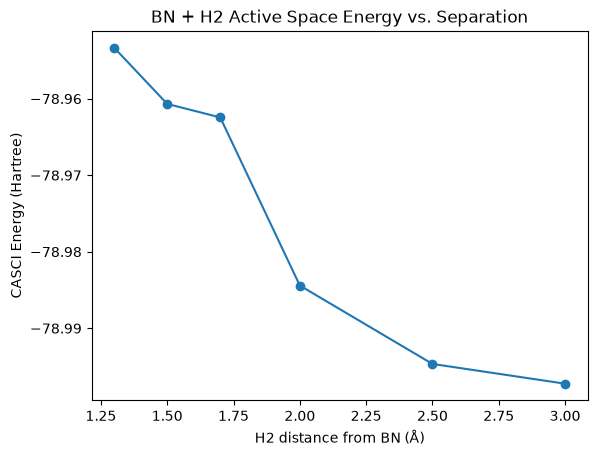

In [5]:
ecas_arr = []
for r in [3.0, 2.5, 2.0, 1.7, 1.5, 1.3]:
    mol, mf, mc, h1eff, ecore, eri_cas = build_bn_h2_active_space(
        h2_distance=r,
        ncas=3,
        nelecas=4,
    )

    e_cas = mc.kernel()[0]
    ecas_arr.append(e_cas)

    print(
        f"H2 distance = {r:4.2f} Å | "
        f"HF = {mf.e_tot:.10f} | "
        f"CASCI = {e_cas:.10f} | "
        f"corr = {e_cas - mf.e_tot:.10f}"
    )

plt.plot(
    [3.0, 2.5, 2.0, 1.7, 1.5, 1.3],
    ecas_arr,
    marker="o",
)
plt.xlabel("H2 distance from BN (Å)")
plt.ylabel("CASCI Energy (Hartree)")
plt.title("BN + H2 Active Space Energy vs. Separation")
plt.show()




In [6]:
def build_bn_h_active_space(
    basis="sto-3g",
    bn_bond=1.281,
    h_distance=1.5,
    ncas=3,
    nelecas=(3, 2),
):
    """
    BN + H radical model.

    Total electrons:
    B = 5, N = 7, H = 1 -> 13 electrons.
    Open-shell doublet.

    ncas = 3 -> 6 qubits
    nelecas = (3, 2) -> 5 active electrons
    """

    mol = gto.Mole()
    mol.atom = f"""
    B   0.000000   0.000000   0.000000
    N   0.000000   0.000000   {bn_bond}
    H   0.000000   0.000000   {-h_distance}
    """
    mol.basis = basis
    mol.charge = 0
    mol.spin = 1       # doublet: N_alpha - N_beta = 1
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.ROHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("ROHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas